# GradeScope — 05. Logika rozmyta (Fuzzy Logic)

**Cel:** ocena wydajności studenta jako wartość ciągła (0–100) zamiast binarnego Pass/Fail  
**Wejście:** `Attendance` (60–100%) i `Hours_Studied` (1–44h) — dwie najważniejsze cechy z EDA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import pickle

## 1. Zmienne lingwistyczne i funkcje przynależności

In [2]:
# Trójkątne funkcje przynależności (trimf) — prosta interpretowalność, wystarczająca precyzja dla 3 poziomów lingwistycznych
# Zmienne wejściowe i wyjściowa
attendance    = ctrl.Antecedent(np.arange(60, 101, 1), "attendance")
hours_studied = ctrl.Antecedent(np.arange(1,  45,  1), "hours_studied")
performance   = ctrl.Consequent(np.arange(0,  101, 1), "performance")

# Funkcje przynależności — attendance
attendance["low"]    = fuzz.trimf(attendance.universe, [60, 60, 75])
attendance["medium"] = fuzz.trimf(attendance.universe, [70, 80, 90])
attendance["high"]   = fuzz.trimf(attendance.universe, [85, 100, 100])

# Funkcje przynależności — hours_studied
hours_studied["low"]    = fuzz.trimf(hours_studied.universe, [1,  1,  15])
hours_studied["medium"] = fuzz.trimf(hours_studied.universe, [10, 20, 30])
hours_studied["high"]   = fuzz.trimf(hours_studied.universe, [25, 44, 44])

# Funkcje przynależności — performance
performance["low"]    = fuzz.trimf(performance.universe, [0,  0,  40])
performance["medium"] = fuzz.trimf(performance.universe, [30, 55, 70])
performance["high"]   = fuzz.trimf(performance.universe, [60, 100, 100])

print("Zmienne lingwistyczne zdefiniowane.")

Zmienne lingwistyczne zdefiniowane.


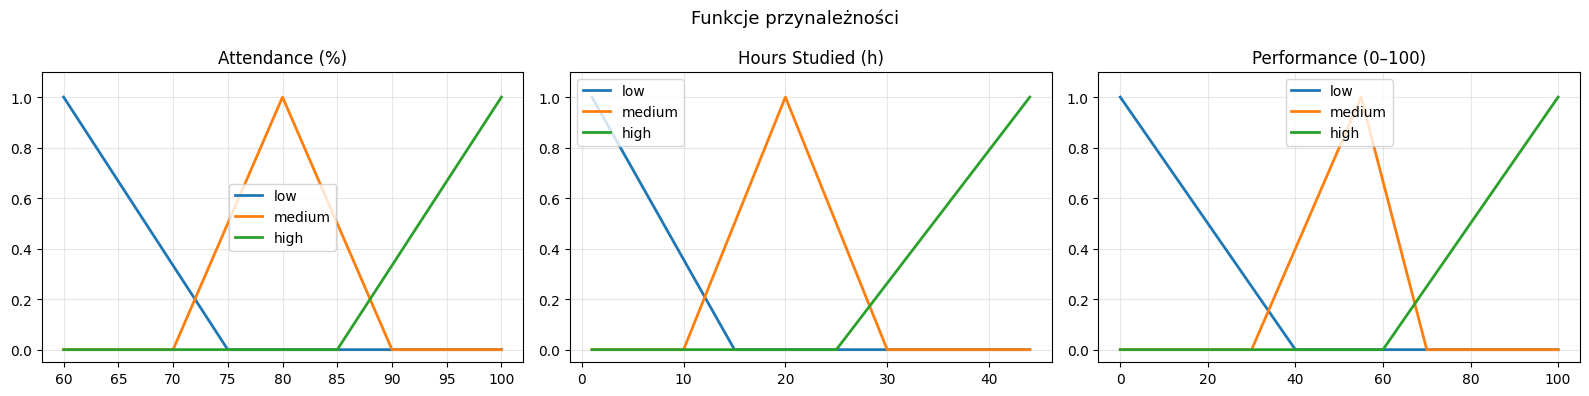

In [3]:
# Wizualizacja funkcji przynależności
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var, title in zip(axes,
    [attendance, hours_studied, performance],
    ["Attendance (%)", "Hours Studied (h)", "Performance (0–100)"]):
    for label in var.terms:
        ax.plot(var.universe, var[label].mf, label=label, linewidth=2)
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Funkcje przynależności", fontsize=13)
plt.tight_layout()
plt.savefig("../report/fig_fuzzy_membership.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Reguły fuzzy

In [4]:
# Reguły — oparte na wnioskach z EDA i drzewa decyzyjnego
rule1 = ctrl.Rule(attendance["high"]   & hours_studied["high"],   performance["high"])
rule2 = ctrl.Rule(attendance["high"]   & hours_studied["medium"], performance["high"])
rule3 = ctrl.Rule(attendance["medium"] & hours_studied["high"],   performance["high"])
rule4 = ctrl.Rule(attendance["medium"] & hours_studied["medium"], performance["medium"])
rule5 = ctrl.Rule(attendance["low"]    & hours_studied["high"],   performance["medium"])
rule6 = ctrl.Rule(attendance["high"]   & hours_studied["low"],    performance["medium"])
rule7 = ctrl.Rule(attendance["medium"] & hours_studied["low"],    performance["low"])
rule8 = ctrl.Rule(attendance["low"]    & hours_studied["medium"], performance["low"])
rule9 = ctrl.Rule(attendance["low"]    & hours_studied["low"],    performance["low"])

# System sterowania
perf_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
perf_sim  = ctrl.ControlSystemSimulation(perf_ctrl)

print("Zdefiniowano 9 reguł fuzzy.")

Zdefiniowano 9 reguł fuzzy.


## 3. Testowanie systemu

In [5]:
# Przykładowe scenariusze
scenarios = [
    ("Wzorowy student",      95, 40),
    ("Przeciętny student",   80, 20),
    ("Student zagrożony",    65, 8),
    ("Pilny, ale nieobecny", 62, 38),
    ("Obecny, ale nie uczy", 92, 5),
]

print(f"{'Scenariusz':<25} {'Attendance':>10} {'Hours':>7} {'Performance':>13}")
print("-" * 58)

for label, att, hrs in scenarios:
    perf_sim.input["attendance"]    = att
    perf_sim.input["hours_studied"] = hrs
    perf_sim.compute()
    score = perf_sim.output["performance"]
    print(f"{label:<25} {att:>10}%  {hrs:>5}h  {score:>10.1f}/100")

Scenariusz                Attendance   Hours   Performance
----------------------------------------------------------
Wzorowy student                   95%     40h        85.6/100
Przeciętny student                80%     20h        51.7/100
Student zagrożony                 65%      8h        15.6/100
Pilny, ale nieobecny              62%     38h        51.4/100
Obecny, ale nie uczy              92%      5h        51.0/100


## 4. Mapa wydajności (surface)

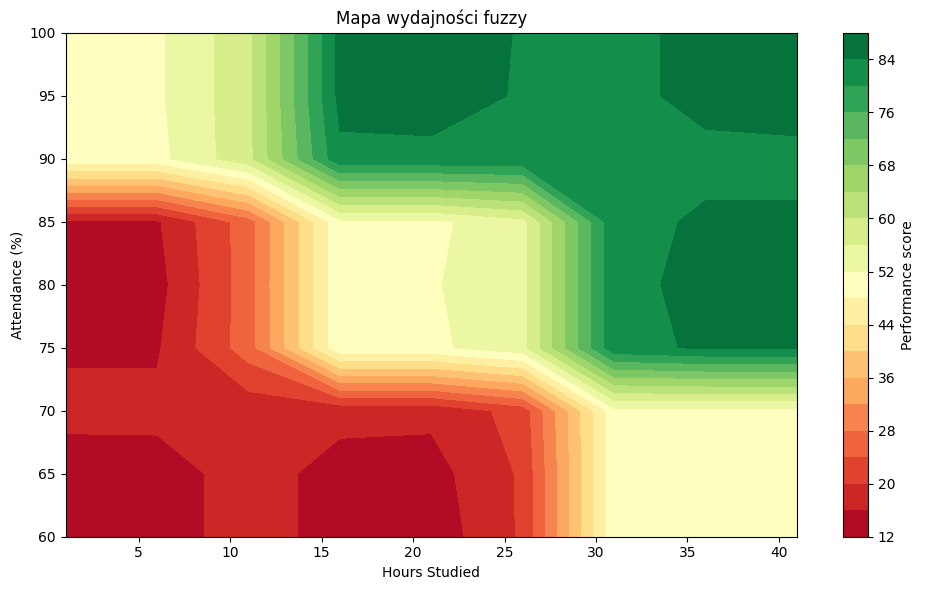

In [6]:
# Siatka wyników dla wszystkich kombinacji wejść
att_range = np.arange(60, 101, 5)
hrs_range = np.arange(1, 45, 5)
Z = np.zeros((len(att_range), len(hrs_range)))

for i, att in enumerate(att_range):
    for j, hrs in enumerate(hrs_range):
        perf_sim.input["attendance"]    = att
        perf_sim.input["hours_studied"] = hrs
        perf_sim.compute()
        Z[i, j] = perf_sim.output["performance"]

# Heatmapa
plt.figure(figsize=(10, 6))
plt.contourf(hrs_range, att_range, Z, levels=20, cmap="RdYlGn")
plt.colorbar(label="Performance score")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance (%)")
plt.title("Mapa wydajności fuzzy")
plt.tight_layout()
plt.savefig("../report/fig_fuzzy_surface.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Zapis systemu fuzzy

In [7]:
# Zapis parametrów fuzzy do JS (frontend odtworzy system bez Pythona)
fuzzy_params = {
    "attendance": {
        "universe": [60, 100],
        "low":    [60, 60, 75],
        "medium": [70, 80, 90],
        "high":   [85, 100, 100],
    },
    "hours_studied": {
        "universe": [1, 44],
        "low":    [1,  1,  15],
        "medium": [10, 20, 30],
        "high":   [25, 44, 44],
    },
    "performance": {
        "universe": [0, 100],
        "low":    [0,  0,  40],
        "medium": [30, 55, 70],
        "high":   [60, 100, 100],
    }
}

with open("../data/fuzzy_params.pkl", "wb") as f:
    pickle.dump(fuzzy_params, f)

import json
with open("../data/fuzzy_params.json", "w") as f:
    json.dump(fuzzy_params, f, indent=2)

print("Zapisano: fuzzy_params.pkl i fuzzy_params.json")

Zapisano: fuzzy_params.pkl i fuzzy_params.json
